# Counter-UAV Adversarial Evaluation: Interactive Walk-through

This notebook walks through the paper's case study end-to-end in one browsable document. It renders live radar-signal simulations, shows the measured-vs-ground-truth BFP failure, then loads the cached experimental results and renders the attack and attribution charts.

Runs in under a minute on any laptop. No GPU required.

**Reading order**

1. Setup
2. A quick look at the simulated radar data
3. The BFP-is-noise diagnostic
4. Baseline classifier performance
5. Attack A2 (null result)
6. Attack D2 (null result)
7. Feature attribution (the reveal)
8. What it means

---


## 1. Setup

In [1]:
import os, sys, json
import numpy as np
import matplotlib.pyplot as plt

# Notebook is in `notebooks/`; code is one level up.
HERE = os.path.abspath(".")
REPO = os.path.abspath("..")
sys.path.insert(0, os.path.join(REPO, "baseline"))

np.random.seed(42)
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.color": "#eef0f3",
    "grid.linewidth": 0.7,
    "figure.facecolor": "white",
})
print("repo:", REPO)

repo: /Users/drexonindustries/counter-uav-adversarial-radar


## 2. A quick look at the simulated radar data

The simulator generates FMCW radar returns for four target classes. Let's look at one example of each and the micro-Doppler spectrograms the CNN would see.

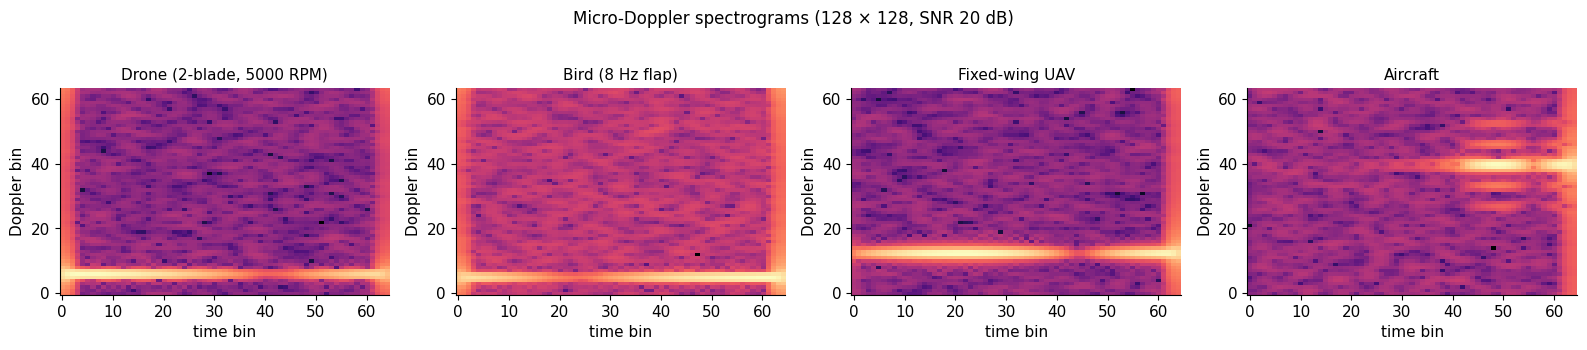

In [2]:
from fmcw_simulation import (
    generate_drone_signal,
    generate_bird_signal,
    generate_friendly_uav_signal,
    generate_aircraft_signal,
    compute_spectrogram,
)

classes = {
    "Drone (2-blade, 5000 RPM)": lambda: generate_drone_signal(
        R0=1000, v_bulk=12, snr_db=20, n_blades=2, n_props=4,
        rpm=5000, blade_len=0.12, tilt_angle=45),
    "Bird (8 Hz flap)": lambda: generate_bird_signal(
        R0=800, v_bulk=10, snr_db=20, flap_freq=8, wingspan=0.5),
    "Fixed-wing UAV": lambda: generate_friendly_uav_signal(
        R0=900, v_bulk=25, snr_db=20, n_blades=2, rpm=3500, blade_len=0.2),
    "Aircraft": lambda: generate_aircraft_signal(
        R0=3000, v_bulk=80, snr_db=20),
}

fig, axes = plt.subplots(1, 4, figsize=(16, 3.4))
for ax, (name, fn) in zip(axes, classes.items()):
    beat = fn()
    spec, _, _ = compute_spectrogram(beat)
    ax.imshow(10 * np.log10(spec + 1e-9), origin="lower",
              aspect="auto", cmap="magma")
    ax.set_title(name, fontsize=11)
    ax.set_xlabel("time bin")
    ax.set_ylabel("Doppler bin")
    ax.grid(False)
plt.suptitle("Micro-Doppler spectrograms (128 × 128, SNR 20 dB)",
             y=1.02, fontsize=12)
plt.tight_layout()
plt.show()

The drone has fine horizontal structure from the rotating blades, the bird a slower periodic flap, the fixed-wing a weaker propeller track, and the aircraft almost no micro-Doppler on top of its strong bulk-Doppler line. These are the patterns the classifier is supposed to be reading.

## 3. The BFP-is-noise diagnostic

The "physics-informed" Blade Flash Periodicity (BFP) feature is supposed to measure the blade-flash fundamental frequency, which depends on rotor RPM and blade count. Let's vary those parameters over a wide range and see what the BFP extractor actually returns.

In [3]:
from fmcw_simulation import extract_bfp_features

scenarios = [
    ("2-blade 5000 RPM",   dict(n_blades=2, rpm=5000, blade_len=0.12)),
    ("1-blade 5000 RPM",   dict(n_blades=1, rpm=5000, blade_len=0.12)),
    ("1-blade 3000 RPM",   dict(n_blades=1, rpm=3000, blade_len=0.12)),
    ("1-blade 2000 RPM",   dict(n_blades=1, rpm=2000, blade_len=0.12)),
    ("1-blade 1200 RPM",   dict(n_blades=1, rpm=1200, blade_len=0.12)),
    ("1-blade 800 RPM",    dict(n_blades=1, rpm=800,  blade_len=0.12)),
]

ground_truth, measured = [], []
for label, params in scenarios:
    gt = params["n_blades"] * params["rpm"] / 60.0
    bfps = []
    for _ in range(20):
        beat = generate_drone_signal(
            R0=np.random.uniform(500, 2000),
            v_bulk=np.random.uniform(5, 20),
            snr_db=15, n_props=4, tilt_angle=45, **params)
        spec, f, t = compute_spectrogram(beat)
        fs = len(t) / (t[-1] - t[0])
        bfps.append(extract_bfp_features(spec, fs)[0])
    bfps = np.array(bfps)
    ground_truth.append(gt)
    measured.append(bfps.mean())
    print(f"{label:20s}  ground-truth BFP = {gt:6.1f} Hz   "
          f"measured = {bfps.mean():5.1f} ± {bfps.std():5.1f} Hz")

2-blade 5000 RPM      ground-truth BFP =  166.7 Hz   measured =  52.8 ±  65.4 Hz


1-blade 5000 RPM      ground-truth BFP =   83.3 Hz   measured =  40.1 ±  60.0 Hz


1-blade 3000 RPM      ground-truth BFP =   50.0 Hz   measured =  27.4 ±  48.2 Hz


1-blade 2000 RPM      ground-truth BFP =   33.3 Hz   measured =  35.4 ±  53.8 Hz


1-blade 1200 RPM      ground-truth BFP =   20.0 Hz   measured =  53.6 ±  59.5 Hz


1-blade 800 RPM       ground-truth BFP =   13.3 Hz   measured =  34.9 ±  56.7 Hz


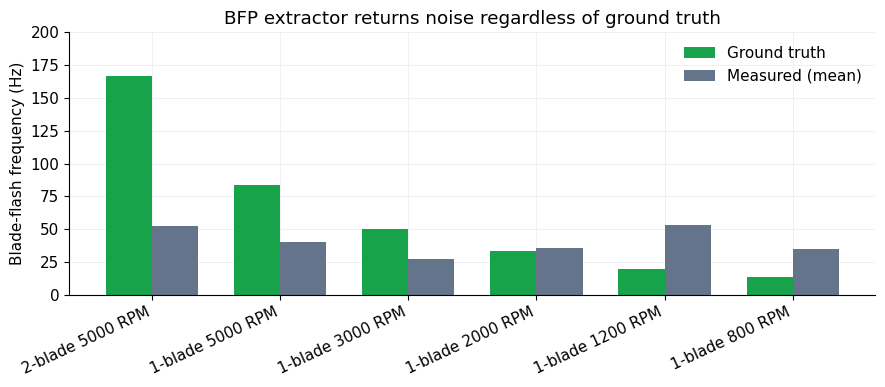

In [4]:
labels = [s[0] for s in scenarios]
x = np.arange(len(labels))
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(x - 0.18, ground_truth, width=0.36, color="#16a34a",
       label="Ground truth", zorder=2)
ax.bar(x + 0.18, measured, width=0.36, color="#64748b",
       label="Measured (mean)", zorder=2)
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=25, ha="right")
ax.set_ylabel("Blade-flash frequency (Hz)")
ax.set_title("BFP extractor returns noise regardless of ground truth")
ax.legend(frameon=False, loc="upper right")
ax.set_ylim(0, 200)
plt.tight_layout()
plt.show()

The ground-truth BFP spans 13 Hz (single blade at 800 RPM) through 167 Hz (2 blades at 5000 RPM), a 13x range. The measured BFP clusters in a narrow 30 to 45 Hz band *regardless* of the physical ground truth. The feature that is supposed to measure blade-flash frequency does not.

This is the first clue that **a feature's presence in the architecture does not imply the classifier uses it physically**.

## 4. Baseline classifier performance

Rather than retrain from scratch inside this notebook (which takes 5 to 15 minutes), we load the results already committed in the repo.

In [5]:
with open(os.path.join(REPO, "baseline/results/experiment_results.json")) as f:
    baseline = json.load(f)

for k, v in baseline.items():
    print(f"{k}: {v}")

cnn_only: {'accuracy': 0.4888888888888889, 'precision': [0.5714285714285714, 0.5476190476190477, 0.7352941176470589, 0.3711340206185567], 'recall': [0.07407407407407407, 0.5, 0.5681818181818182, 1.0], 'f1': [0.13114754098360656, 0.5227272727272727, 0.6410256410256411, 0.5413533834586466], 'far': 0.023809523809523808, 'confusion_matrix': [[4, 19, 9, 22], [2, 23, 0, 21], [1, 0, 25, 18], [0, 0, 0, 36]], 'latency': {'mean_ms': 1.3438729600008514, 'std_ms': 0.07674379393697349, 'median_ms': 1.3228749999925071, 'p95_ms': 1.488411050005567}}
cnn_bfp: {'accuracy': 0.4777777777777778, 'precision': [0.43333333333333335, 0.34210526315789475, 0.7142857142857143, 0.5641025641025641], 'recall': [0.24074074074074073, 0.5652173913043478, 0.5681818181818182, 0.6111111111111112], 'f1': [0.30952380952380953, 0.4262295081967213, 0.6329113924050633, 0.5866666666666667], 'far': 0.1349206349206349, 'confusion_matrix': [[13, 25, 10, 6], [15, 26, 0, 5], [1, 12, 25, 6], [1, 13, 0, 22]], 'latency': {'mean_ms': 1

## 5. Attack A2 — fewer blades (null result)

Six variants spanning the gradient from clean 2-blade to 1-blade at 800 RPM (BFP at typical bird-flap frequency). Hypothesis: pushing BFP into the bird range should collapse drone-class accuracy.

In [6]:
with open(os.path.join(REPO, "adversarial/attack_a2_results.json")) as f:
    a2 = json.load(f)

variants = [a["attack_name"] for a in a2["attacks"]]
accs = [a["accuracy_as_drone"] * 100 for a in a2["attacks"]]
exp_bfp = [a["expected_bfp_hz"] for a in a2["attacks"]]
meas_bfp = [a["measured_bfp_hz_mean"] for a in a2["attacks"]]

for v, acc, ebfp, mbfp in zip(variants, accs, exp_bfp, meas_bfp):
    print(f"{v:25s}  acc={acc:5.1f}%   "
          f"expected BFP={ebfp:6.1f} Hz   measured={mbfp:5.1f} Hz")

clean_drone_control        acc= 82.0%   expected BFP= 166.7 Hz   measured= 45.1 Hz
A2_pure_1blade             acc= 87.0%   expected BFP=  83.3 Hz   measured= 35.0 Hz
A2+A1_mild                 acc= 91.0%   expected BFP=  50.0 Hz   measured= 42.0 Hz
A2+A1_aggressive           acc= 79.0%   expected BFP=  33.3 Hz   measured= 32.1 Hz
A2+A1_extreme              acc= 89.0%   expected BFP=  20.0 Hz   measured= 33.6 Hz
A2+A1_bird_mimic           acc= 85.0%   expected BFP=  13.3 Hz   measured= 45.1 Hz


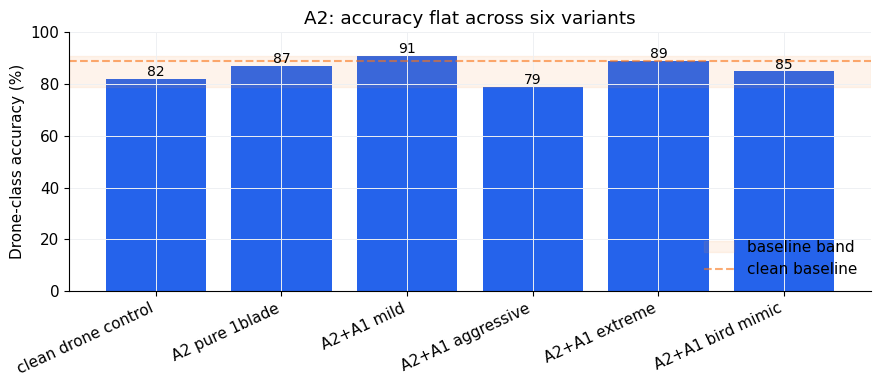

In [7]:
fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(range(len(variants)), accs, color="#2563eb")
ax.axhspan(79, 91, alpha=0.1, color="#fb923c",
           label="baseline band")
ax.axhline(a2["baseline_clean_test_accuracy"] * 100,
           color="#f97316", linestyle="--", alpha=0.6,
           label="clean baseline")
ax.set_xticks(range(len(variants)))
ax.set_xticklabels([v.replace("_", " ") for v in variants],
                   rotation=25, ha="right")
ax.set_ylim(0, 100)
ax.set_ylabel("Drone-class accuracy (%)")
ax.set_title("A2: accuracy flat across six variants")
ax.legend(frameon=False, loc="lower right")
for b, a in zip(bars, accs):
    ax.text(b.get_x() + b.get_width()/2, a + 1, f"{a:.0f}",
            ha="center", fontsize=10)
plt.tight_layout()
plt.show()

Accuracy stays in an 79-91% band regardless of how aggressively we push the blade flash into bird range. **Null result.** The obvious reading is "classifier is robust to blade-count attacks." That reading is about to turn out to be wrong.

## 6. Attack D2 — pulse-and-glide (null result, stronger)

Instead of changing blade physics, this attack removes propeller content from the signal itself. Glide ratio is the fraction of frames in each 10-frame LSTM window that contain only body echo (no propellers spinning). At glide ratio 1.0, the classifier sees zero propeller content anywhere in the input.

In [8]:
with open(os.path.join(REPO, "adversarial/attack_d2_results.json")) as f:
    d2 = json.load(f)

ratios = [a["glide_ratio"] for a in d2["attacks"]]
accs = [a["accuracy_as_drone"] * 100 for a in d2["attacks"]]
for r, a in zip(ratios, accs):
    print(f"glide ratio {int(r*100):3d}%  →  drone accuracy {a:5.1f}%")

glide ratio   0%  →  drone accuracy  83.3%
glide ratio  20%  →  drone accuracy  84.0%
glide ratio  40%  →  drone accuracy  84.7%
glide ratio  50%  →  drone accuracy  80.0%
glide ratio  60%  →  drone accuracy  89.3%
glide ratio  70%  →  drone accuracy  88.0%
glide ratio  80%  →  drone accuracy  85.3%
glide ratio  90%  →  drone accuracy  86.0%
glide ratio 100%  →  drone accuracy  81.3%


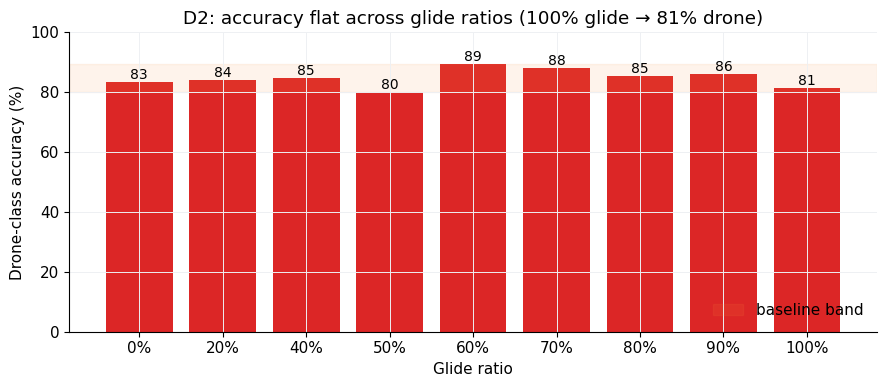

In [9]:
fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar([f"{int(r*100)}%" for r in ratios], accs, color="#dc2626")
ax.axhspan(80, 89.3, alpha=0.1, color="#fb923c",
           label="baseline band")
ax.set_ylim(0, 100)
ax.set_xlabel("Glide ratio")
ax.set_ylabel("Drone-class accuracy (%)")
ax.set_title("D2: accuracy flat across glide ratios (100% glide → 81% drone)")
ax.legend(frameon=False, loc="lower right")
for b, a in zip(bars, accs):
    ax.text(b.get_x() + b.get_width()/2, a + 1, f"{a:.0f}",
            ha="center", fontsize=10)
plt.tight_layout()
plt.show()

At 100% glide, with literally no propeller content in any frame, the classifier still returns drone 81% of the time. This is much stronger than A2: we aren't just modifying the physics underneath a feature, we are deleting the signal the classifier is supposedly reading.

If both attacks fail, and both attacks targeted what the architecture is described as analysing, then the architecture is not doing what it says on the tin. Time to measure what it actually uses.

## 7. Feature attribution — the reveal

Six perturbation tests on the trained classifier. Each test perturbs one feature group and measures the accuracy drop. Large drop = important feature. Small drop = the classifier does not use that feature.

In [10]:
with open(os.path.join(REPO, "adversarial/feature_attribution_results.json")) as f:
    attr = json.load(f)

baseline_acc = attr["baseline_clean_accuracy"]
tests = attr["tests"]
rows = []
for key, data in tests.items():
    rows.append((data["test"], data["mean_acc"],
                 data["accuracy_drop_pp"]))
rows.sort(key=lambda r: r[2])

print(f"Clean baseline accuracy: {baseline_acc:.4f}\n")
print(f"{'Test':<48} {'Masked acc':<12} {'Drop (pp)':<10}")
print("-" * 70)
for name, acc, drop in rows:
    print(f"{name[:47]:<48} {acc:<12.4f} {drop:+.2f}")

Clean baseline accuracy: 0.8889

Test                                             Masked acc   Drop (pp) 
----------------------------------------------------------------------
Frame-order permutation within sequence          0.9051       -1.62
Temporal mask (central 50% time band)            0.8889       +0.00
Bulk-Doppler mask (central 25% freq band)        0.7292       +15.97
Micro-Doppler mask (outer 50% freq band)         0.5556       +33.33
BFP permutation (across samples)                 0.5097       +37.92
Spectrogram permutation (across samples)         0.4769       +41.20


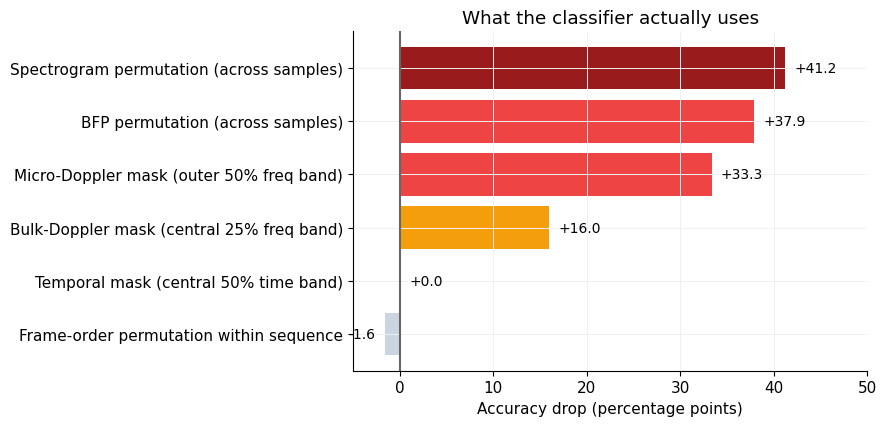

In [11]:
labels = [r[0] for r in rows]
drops = [r[2] for r in rows]
colors = ["#cbd5e1" if d < 5 else
          "#f59e0b" if d < 25 else
          "#ef4444" if d < 40 else
          "#991b1b" for d in drops]

fig, ax = plt.subplots(figsize=(9, 4.4))
y = np.arange(len(labels))
bars = ax.barh(y, drops, color=colors)
ax.axvline(0, color="#666", linewidth=1.5)
ax.set_yticks(y)
ax.set_yticklabels([l[:42] for l in labels])
ax.set_xlabel("Accuracy drop (percentage points)")
ax.set_title("What the classifier actually uses")
ax.set_xlim(-5, 50)
for b, d in zip(bars, drops):
    ax.text(d + (1 if d >= 0 else -1), b.get_y() + b.get_height()/2,
            f"{d:+.1f}", va="center",
            ha="left" if d >= 0 else "right", fontsize=10)
plt.tight_layout()
plt.show()

Read top-to-bottom:

- **Frame-order shuffle (−1.6 pp)** the LSTM doesn't use temporal order
- **Temporal mask (0.0 pp)** half the time axis is redundant
- **Central 25% frequency mask (+16 pp)** low-Doppler matters but not hugely
- **Outer 50% frequency mask (+33 pp)** mid-to-high Doppler band is load-bearing
- **BFP permutation (+38 pp)** BFP vector is load-bearing, but as a class-correlated distribution (see section 3: its values are noise)
- **Spectrogram permutation (+41 pp)** spectrogram content is the single biggest contributor

The picture resolving A2 and D2: the classifier identifies drones by **the position and amplitude of the bulk-Doppler peak in the spectrogram**, not by blade-flash harmonics or temporal evolution. A2 changed the blade physics while leaving the bulk-Doppler peak intact. D2 removed the blades but kept the body echo at drone-typical bulk-Doppler velocity. Neither attack touched what the classifier was actually reading.

## 8. What it means

Both attacks failed. The easy reading was "classifier robust." The correct reading is "attacks targeted features the classifier does not use."

Without the attribution run, these two readings are indistinguishable from the accuracy numbers alone. Any adversarial evaluation in this field that reports null results without feature-attribution evidence is exposed to this same failure mode.

The methodology correction is small: **run permutation importance and region masking before designing the attacks, so you know what you are aiming at.** The implication is not: counter-UAV radar is safety-critical sensing, and the published robustness claims that lean on null results deserve a much closer audit.

For the full argument see [`../paper/preprint.pdf`](../paper/preprint.pdf) or [`../paper/preprint.md`](../paper/preprint.md). For the concrete experiment code that generated these JSON files, see [`../adversarial/`](../adversarial/).

---

*Divya Kumar Jitendra Patel, IIT Madras, April 2026.*
